<center><h1>A notebook for training the model for regression</h1></center>

# Imports 

In [1]:
import torch
from torch.utils.data import DataLoader

import torchvision.transforms as transforms
from torch import nn
import torch.nn.functional as F


import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm.auto import tqdm

from sklearn.metrics import mean_absolute_error, r2_score

import helper

# Dataset

The definition of transforms applied to the images

In [ ]:
TF = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((300, 300)),
    transforms.Normalize((0.5,), (0.5,))
])

Loading the dataset from directory using the self-written module helper.py 

In [ ]:
dataset = helper.load_dataset('datasets/all13-reg.pth', transform=TF, floatlabels=True)

# Constants 

The definitions of constants used for training

In [2]:
BATCH_SIZE = 16
EPOCHS = 10

HIDDEN_LAYER_FEATURES = [32, 64, 96]

LEARNING_RATE = 0.001

Initializing the GPU for training

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Functions 
A function for evaluating the model that computes mean squared error and $R^2$-score

In [3]:
def evaluate(model, loader, device):
    metrics = defaultdict(lambda: list())
    all_true = []
    all_pred = []
    
    for k, (X, y)  in tqdm(enumerate(loader), total=len(loader)):
        X, y = X.to(device), y.to(device)

        predictions = model(X)
        
        y_true_np = y.cpu().detach().numpy().flatten()
        y_pred_np = predictions.cpu().detach().numpy().flatten()
        

        all_true.extend(y_true_np)
        all_pred.extend(y_pred_np)
        
    print(all_true[-5:], all_pred[-5:])

    metrics['mse'] = mean_absolute_error(all_true, all_pred)
    metrics['r2'] = r2_score(all_true, all_pred)

    return metrics

# Training

## Train-Test split

In [6]:
train_dataset, test_dataset = helper.split(dataset, test_size=0.2)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## A dictionary for saving history

In [7]:
history = defaultdict(lambda:list())

## Architecture

It is the same as for the classification, except the output shape of one

In [8]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, HIDDEN_LAYER_FEATURES[0], 3, padding=1)
        self.conv2 = nn.Conv2d(HIDDEN_LAYER_FEATURES[0], HIDDEN_LAYER_FEATURES[1], 3, padding=1)
        self.conv3 = nn.Conv2d(HIDDEN_LAYER_FEATURES[1], HIDDEN_LAYER_FEATURES[2], 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.global_avg_pool = nn.AdaptiveAvgPool2d((3, 3))
        self.dropout = nn.Dropout(0.1)
        self.fc1 = nn.Linear(HIDDEN_LAYER_FEATURES[2] * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(self.dropout(x)))
        x = self.fc2(x)  
        return x


## Initialization of the model

Here, we initialize the model and move it to the GPU
Moreover, the optimizer and loss are defined here either

In [9]:
model = CNN().to(DEVICE)
criterion = nn.MSELoss()  
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Training

A special loop for training 
For every epoch we compute metrics for testing and training set

In [11]:
for epoch in range(EPOCHS):
    print(f"epoch {epoch + 1} ({epoch + 1}/{EPOCHS}):")

    for inputs, labels  in tqdm(train_loader, total=len(train_loader)):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), labels.squeeze())

        optimizer.zero_grad() 
        loss.backward()
        optimizer.step()

    train_metrics = evaluate(model, train_loader, DEVICE)
    test_metrics = evaluate(model, test_loader, DEVICE)

    history['train_mse'].append(train_metrics['mse'])
    history['test_mse'].append(test_metrics['mse'])
    
    history['train_r2'].append(train_metrics['r2'])
    history['test_r2'].append(test_metrics['r2'])

    history['loss'].append(loss.cpu().data.numpy())
    
    print("train_mse:", history['train_mse'][-1])
    print("test_mse:", history['test_mse'][-1], end='\n')
    
    print("train_r2:", history['train_r2'][-1])
    print("test_r2:", history['test_r2'][-1], end='\n')
    
    print("loss:", history['loss'][-1], end="\n\n")


epoch 1 (1/10):


  0%|          | 0/2201 [00:00<?, ?it/s]

  0%|          | 0/2201 [00:00<?, ?it/s]

[0.75544864, 0.42092016, 0.58998394, 0.42808518, 0.42715615] [0.73540086, 0.41993958, 0.5853111, 0.41704994, 0.42925066]


  0%|          | 0/551 [00:00<?, ?it/s]

...

  0%|          | 0/2201 [00:00<?, ?it/s]

  0%|          | 0/2201 [00:00<?, ?it/s]

[0.41545168, 0.43879008, 0.2910296, 0.4169057, 0.31267893] [0.4256514, 0.43480623, 0.30164355, 0.42947647, 0.3061299]


  0%|          | 0/551 [00:00<?, ?it/s]

[0.35508105, 0.40342712, 0.43672165, 0.4750837, 0.40219563] [0.3479208, 0.4283462, 0.43509203, 0.4810002, 0.41446954]
train_mse: 0.0374918
test_mse: 0.03711691
train_r2: 0.9929050179434108
test_r2: 0.9915484513131104
loss: 0.001088437



# Visualization 

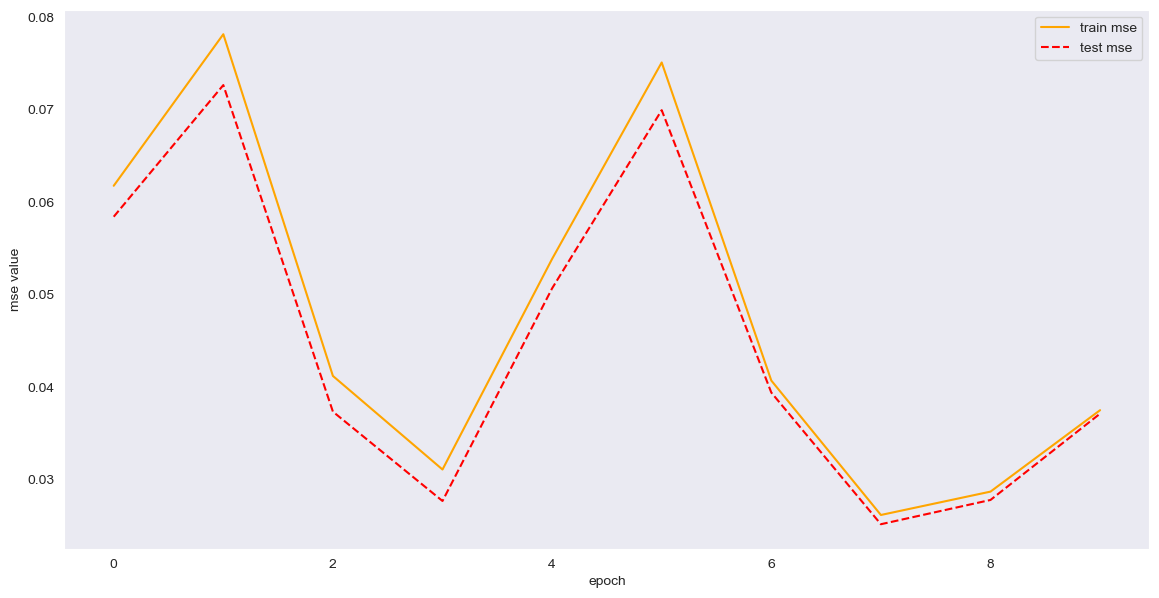

In [26]:
plt.figure(figsize=(14, 7))
plt.plot(history['train_mse'], color='orange', label='train mse')
plt.plot(history['test_mse'], color='red', label='test mse', linestyle='--')

plt.legend()
plt.grid()
plt.xlabel("epoch")
plt.ylabel("mse value")

plt.savefig('figures/all-reg_mse.png')

plt.show()

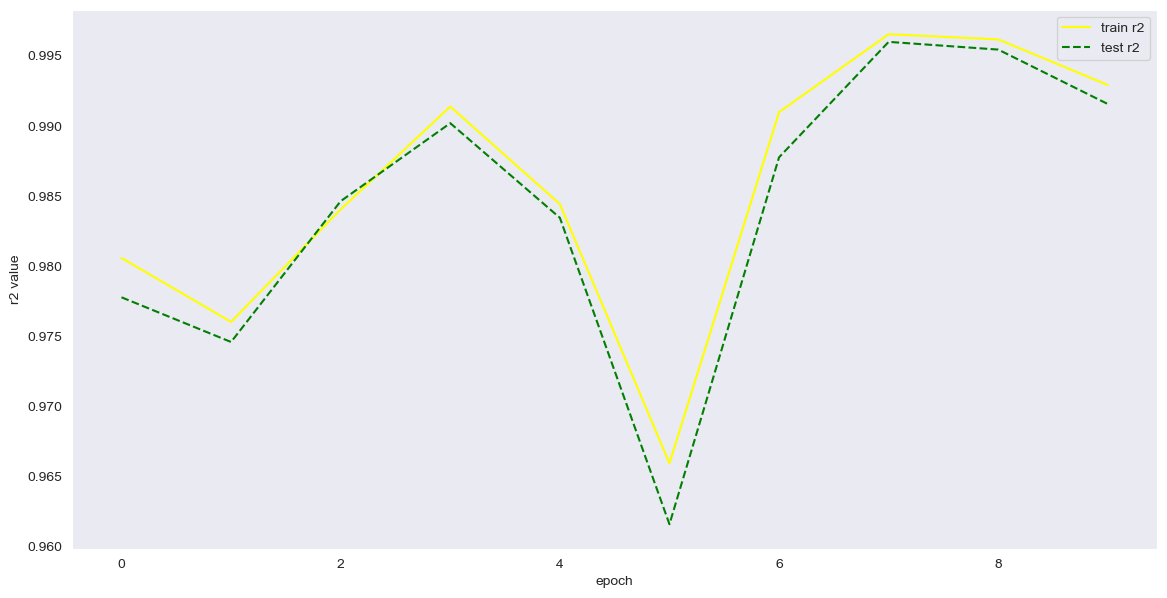

In [27]:
plt.figure(figsize=(14, 7))
plt.plot(history['train_r2'], color='yellow', label='train r2')
plt.plot(history['test_r2'], color='green', label='test r2', linestyle='--')

plt.legend()
plt.grid()
plt.xlabel("epoch")
plt.ylabel("r2 value")

plt.savefig('figures/all-reg_r2.png')

plt.show()

# Saving the model

In [28]:
# torch.save(model.state_dict(), f'models/all13-reg_state_dict.pth')